In [103]:
pip install pulp

Note: you may need to restart the kernel to use updated packages.


In [143]:
import pulp

In [152]:
#Task 1
#Define model and type = minimize
model = pulp.LpProblem(name = 'HOS', sense = pulp.LpMinimize)

#Create sets 
student = ['EK','YC','AT','RZ','RP','CS']
daysofweek = ['Mon','Tue','Wed','Thu','Fri']
avai = {
    ('EK','Mon'): 6, ('EK','Tue'): 0, ('EK','Wed'): 6, ('EK','Thu'): 0, ('EK','Fri'): 6,
    ('YC','Mon'): 0, ('YC','Tue'): 6, ('YC','Wed'): 0, ('YC','Thu'): 6, ('YC','Fri'): 0,
    ('AT','Mon'): 4, ('AT','Tue'): 8, ('AT','Wed'): 4, ('AT','Thu'): 0, ('AT','Fri'): 4,
    ('RZ','Mon'): 5, ('RZ','Tue'): 5, ('RZ','Wed'): 5, ('RZ','Thu'): 0, ('RZ','Fri'): 5,
    ('RP','Mon'): 3, ('RP','Tue'): 0, ('RP','Wed'): 3, ('RP','Thu'): 8, ('RP','Fri'): 0,
    ('CS','Mon'): 0, ('CS','Tue'): 0, ('CS','Wed'): 0, ('CS','Thu'): 6, ('CS','Fri'): 2,
}
wage = {
    'EK':25,'YC':26,'AT':24,'RZ':23,'RP':28,'CS':30
}
min_working = {
    'EK':8,'YC':8,'AT':8,'RZ':8,'RP':7,'CS':7
}
operate_time = 14

#Create decision variable
x = pulp.LpVariable.dicts('Working time per day',(student,daysofweek),lowBound = 0)

#Create constraint
model += pulp.lpSum(wage[s]*x[s][d] for s in student for d in daysofweek)

#Availability constraint
for s in student:
    for d in daysofweek:
        model += x[s][d]<= avai[(s,d)]
#Minimum working time
for s in student:
    model += pulp.lpSum(x[s][d] for d in daysofweek)>= min_working[s]
    
#Total Working Hours
for d in daysofweek:
    model += pulp.lpSum(x[s][d] for s in student) == operate_time
    
model.solve()
print(pulp.value(model.objective))
schedule1a = pd.DataFrame(
    {d: [x[s][d].value() for s in student] for d in daysofweek},
    index=student
)
schedule1a["WeeklyTotal"] = schedule1a.sum(axis=1)
print(schedule1a)



Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/spearxz/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/32440193482e432f88c292153e1842af-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/32440193482e432f88c292153e1842af-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 46 COLUMNS
At line 167 RHS
At line 209 BOUNDS
At line 210 ENDATA
Problem MODEL has 41 rows, 30 columns and 90 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 11 (-30) rows, 18 (-12) columns and 36 (-54) elements
0  Obj 669.79995 Primal inf 64.599993 (11)
11  Obj 1755
Optimal - objective value 1755
After Postsolve, objective 1755, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 1755 - 11 iterations time 0.002, Presolve 0.00
Option for 

In [147]:
base_model = pulp.value(model.objective)
print(base_model)
#Task2.1
model1 = pulp.LpProblem('Fair_distribution_of_time', sense = pulp.LpMinimize)

#Create sets 
student = ['EK','YC','AT','RZ','RP','CS']
daysofweek = ['Mon','Tue','Wed','Thu','Fri']
avai = {
    ('EK','Mon'): 6, ('EK','Tue'): 0, ('EK','Wed'): 6, ('EK','Thu'): 0, ('EK','Fri'): 6,
    ('YC','Mon'): 0, ('YC','Tue'): 6, ('YC','Wed'): 0, ('YC','Thu'): 6, ('YC','Fri'): 0,
    ('AT','Mon'): 4, ('AT','Tue'): 8, ('AT','Wed'): 4, ('AT','Thu'): 0, ('AT','Fri'): 4,
    ('RZ','Mon'): 5, ('RZ','Tue'): 5, ('RZ','Wed'): 5, ('RZ','Thu'): 0, ('RZ','Fri'): 5,
    ('RP','Mon'): 3, ('RP','Tue'): 0, ('RP','Wed'): 3, ('RP','Thu'): 8, ('RP','Fri'): 0,
    ('CS','Mon'): 0, ('CS','Tue'): 0, ('CS','Wed'): 0, ('CS','Thu'): 6, ('CS','Fri'): 2,
}
wage = {
    'EK':25,'YC':26,'AT':24,'RZ':23,'RP':28,'CS':30
}
min_working = {
    'EK':8,'YC':8,'AT':8,'RZ':8,'RP':7,'CS':7
}
operate_time = 14

#Create decision variable
x = pulp.LpVariable.dicts('Working time per day',(student,daysofweek),lowBound = 0)
x_max = pulp.LpVariable('Time max', lowBound = 0)
x_min = pulp.LpVariable('Time min', lowBound = 0)

#Create constraint
model1 += x_max-x_min

#Availability constraint
for s in student:
    for d in daysofweek:
        model1 += x[s][d]<= avai[(s,d)]
#Minimum working time
for s in student:
    model1 += pulp.lpSum(x[s][d] for d in daysofweek)>= min_working[s]
    
#Total Working Hours
for d in daysofweek:
    model1 += pulp.lpSum(x[s][d] for s in student) == operate_time
    
#Max&Min
for s in student:
    model1 += pulp.lpSum(x[s][d] for d in daysofweek)>= x_min
    model1 += pulp.lpSum(x[s][d] for d in daysofweek)<= x_max
    
#cost
model1 += pulp.lpSum(wage[s]*x[s][d] for s in student for d in daysofweek)<= 1.018*base_model,''

model1.solve(pulp.PULP_CBC_CMD(msg=True))
print(pulp.value(model1.objective))
print(pulp.value(pulp.lpSum(wage[s]*x[s][d] for s in student for d in daysofweek)))
print("Status:", pulp.LpStatus[model1.status])
schedule2a = pd.DataFrame(
    {d: [x[s][d].value() for s in student] for d in daysofweek},
    index=student
)
schedule2a["WeeklyTotal"] = schedule2a.sum(axis=1)
print(schedule2a)

1755.0
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/spearxz/anaconda3/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/2783a20899b14010a74c99cc377432e3-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/sz/b69qm0f158l1b3b8gcxb396c0000gn/T/2783a20899b14010a74c99cc377432e3-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 59 COLUMNS
At line 254 RHS
At line 309 BOUNDS
At line 310 ENDATA
Problem MODEL has 54 rows, 32 columns and 192 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 24 (-30) rows, 20 (-12) columns and 102 (-90) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 9.4100543e-05 ( 0.0094100543%) - largest zero change 9.3128486e-05
0  Obj 6.9026955 Primal inf 64.599993 (11) Dual inf 0.99994033 (1)
15  Obj 6.0071606
Optimal - objective

In [150]:
#Task2.2
model2 = pulp.LpProblem('Fair_distribution_of_time', sense = pulp.LpMinimize)

#Create sets 
student = ['EK','YC','AT','RZ','RP','CS']
daysofweek = ['Mon','Tue','Wed','Thu','Fri']
avai = {
    ('EK','Mon'): 6, ('EK','Tue'): 0, ('EK','Wed'): 6, ('EK','Thu'): 0, ('EK','Fri'): 6,
    ('YC','Mon'): 0, ('YC','Tue'): 6, ('YC','Wed'): 0, ('YC','Thu'): 6, ('YC','Fri'): 0,
    ('AT','Mon'): 4, ('AT','Tue'): 8, ('AT','Wed'): 4, ('AT','Thu'): 0, ('AT','Fri'): 4,
    ('RZ','Mon'): 5, ('RZ','Tue'): 5, ('RZ','Wed'): 5, ('RZ','Thu'): 0, ('RZ','Fri'): 5,
    ('RP','Mon'): 3, ('RP','Tue'): 0, ('RP','Wed'): 3, ('RP','Thu'): 8, ('RP','Fri'): 0,
    ('CS','Mon'): 0, ('CS','Tue'): 0, ('CS','Wed'): 0, ('CS','Thu'): 6, ('CS','Fri'): 2,
}
wage = {
    'EK':25,'YC':26,'AT':24,'RZ':23,'RP':28,'CS':30
}
min_working = {
    'EK':8,'YC':8,'AT':8,'RZ':8,'RP':7,'CS':7
}
operate_time = 14

#Create decision variable
x = pulp.LpVariable.dicts('Working time per day',(student,daysofweek),lowBound = 0)
x_max = pulp.LpVariable('Time max', lowBound = 0)
x_min = pulp.LpVariable('Time min', lowBound = 0)

#Create constraint
model2 += pulp.lpSum(wage[s]*x[s][d] for s in student for d in daysofweek)/base_model

#Availability constraint
for s in student:
    for d in daysofweek:
        model2 += x[s][d]<= avai[(s,d)]
#Minimum working time
for s in student:
    model2 += pulp.lpSum(x[s][d] for d in daysofweek)>= min_working[s]
    
#Total Working Hours
for d in daysofweek:
    model2 += pulp.lpSum(x[s][d] for s in student) == operate_time
    
#Max&Min
for s in student:
    model2 += pulp.lpSum(x[s][d] for d in daysofweek)>= x_min
    model2 += pulp.lpSum(x[s][d] for d in daysofweek)<= x_max

#fairness
model2 += x_max-x_min <= 6
    
model2.solve(pulp.PULP_CBC_CMD(msg=False))
print(pulp.value(model1.objective))
print(pulp.value(pulp.lpSum(wage[s]*x[s][d] for s in student for d in daysofweek)))
print("Status:", pulp.LpStatus[model1.status])
schedule2a = pd.DataFrame(
    {d: [x[s][d].value() for s in student] for d in daysofweek},
    index=student
)
schedule2a["WeeklyTotal"] = schedule2a.sum(axis=1)
print(schedule2a)

6.0
1784.0
Status: Optimal
    Mon  Tue  Wed  Thu  Fri  WeeklyTotal
EK  6.0  0.0  2.0  0.0  6.0         14.0
YC  0.0  6.0  0.0  6.0  0.0         12.0
AT  0.0  6.0  4.0  0.0  4.0         14.0
RZ  5.0  2.0  5.0  0.0  2.0         14.0
RP  3.0  0.0  3.0  2.0  0.0          8.0
CS  0.0  0.0  0.0  6.0  2.0          8.0


In [146]:
# Task 3: Skill-based operation

model3 = pulp.LpProblem('Operation_skill', sense = pulp.LpMinimize) #Create sets 
student = ['EK','YC','AT','RZ','RP','CS'] 
daysofweek = ['Mon','Tue','Wed','Thu','Fri'] 
skills = ["Programming", "Troubleshooting"] 

skill_map = { 
             ("EK","Troubleshooting"): 1, ("EK","Programming"): 0, 
             ("YC","Troubleshooting"): 1, ("YC","Programming"): 0, 
             ("AT","Troubleshooting"): 0, ("AT","Programming"): 1, 
             ("RZ","Troubleshooting"): 0, ("RZ","Programming"): 1, 
             ("RP","Troubleshooting"): 1, ("RP","Programming"): 0, 
             ("CS","Troubleshooting"): 1, ("CS","Programming"): 1, 
            } 

avai = {
        ('EK','Mon'): 6, ('EK','Tue'): 0, ('EK','Wed'): 6, ('EK','Thu'): 0, ('EK','Fri'): 6, 
        ('YC','Mon'): 0, ('YC','Tue'): 6, ('YC','Wed'): 0, ('YC','Thu'): 6, ('YC','Fri'): 0, 
        ('AT','Mon'): 4, ('AT','Tue'): 8, ('AT','Wed'): 4, ('AT','Thu'): 0, ('AT','Fri'): 4, 
        ('RZ','Mon'): 5, ('RZ','Tue'): 5, ('RZ','Wed'): 5, ('RZ','Thu'): 0, ('RZ','Fri'): 5, 
        ('RP','Mon'): 3, ('RP','Tue'): 0, ('RP','Wed'): 3, ('RP','Thu'): 8, ('RP','Fri'): 0, 
        ('CS','Mon'): 0, ('CS','Tue'): 0, ('CS','Wed'): 0, ('CS','Thu'): 6, ('CS','Fri'): 2, 
       } 

wage = { 'EK':25,'YC':26,'AT':24,'RZ':23,'RP':28,'CS':30 }

min_working = { 'EK':8,'YC':8,'AT':8,'RZ':8,'RP':7,'CS':7 }

operate_time = 14
#Create decision variable 
x = pulp.LpVariable.dicts('Working time per day',(student,daysofweek),lowBound = 0) 

#Create constraint

model3 += pulp.lpSum(wage[s]*x[s][d] for s in student for d in daysofweek) 
#Availability constraint 
for s in student: 
    for d in daysofweek: 
        model3 += x[s][d]<= avai[(s,d)] 

#Minimum working time
for s in student: 
    model3 += pulp.lpSum(x[s][d] for d in daysofweek)>= min_working[s]
    
#Total Working Hours        
for d in daysofweek: 
    model3 += pulp.lpSum(x[s][d] for s in student) == operate_time 

#Operation skill
for d in daysofweek: 
    for sk in skills: model3 += pulp.lpSum(x[s][d] * skill_map[(s,sk)] for s in student) >=6
        
# Solve
model3.solve(pulp.PULP_CBC_CMD(msg=False))

print("Status:", pulp.LpStatus[model3.status])
print("Task 3 cost:", pulp.value(model3.objective))
schedule2a = pd.DataFrame( {d: [x[s][d].value() for s in student] for d in daysofweek}, index=student ) 
schedule2a["WeeklyTotal"] = schedule2a.sum(axis=1) 
print(schedule2a)

Status: Optimal
Task 3 cost: 1762.0
    Mon  Tue  Wed  Thu  Fri  WeeklyTotal
EK  5.0  0.0  6.0  0.0  5.0         16.0
YC  0.0  6.0  0.0  2.0  0.0          8.0
AT  3.0  3.0  3.0  0.0  3.0         12.0
RZ  5.0  5.0  5.0  0.0  5.0         20.0
RP  1.0  0.0  0.0  6.0  0.0          7.0
CS  0.0  0.0  0.0  6.0  1.0          7.0


In [31]:
# import sys
# !{sys.executable} -m pip uninstall -y scikit-learn imbalanced-learn
# !{sys.executable} -m pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
from sklearn.model_selection import cross_val_score,cross_validate, train_test_split, RandomizedSearchCV, GridSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder, OrdinalEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC


In [35]:
# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("AED4weeks.csv")

# -----------------------------
# Draw random sample (reproducible)
# -----------------------------
RANDOM_SEED = 42
sample = df.sample(n=400, random_state=RANDOM_SEED)
sample['LoSh'] = sample['LoS']/60
df

,ID,Age,Day,DayofWeek,Period,LoS,Breachornot,HRG,noofinvestigation,nooftreatment,noofpatients
0,P10000,4,1,Monday,0,197,non-breach,VB11Z,0,1,25
1,P10001,16,1,Monday,0,66,non-breach,VB11Z,0,1,26
2,P10002,1,1,Monday,0,233,non-breach,VB09Z,0,1,27
3,P10003,31,1,Monday,0,206,non-breach,VB03Z,6,1,26
4,P10004,59,1,Monday,0,232,non-breach,VB08Z,4,1,25
...,...,...,...,...,...,...,...,...,...,...,...
8776,P18776,18,28,Sunday,22,235,non-breach,VB08Z,4,1,49
8777,P18777,48,28,Sunday,22,93,non-breach,VB11Z,0,1,49
8778,P18778,57,28,Sunday,23,188,non-breach,VB09Z,0,1,47
8779,P18779,45,28,Sunday,23,215,non-breach,VB07Z,3,2,42


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8781 entries, 0 to 8780
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 8781 non-null   object
 1   Age                8781 non-null   int64 
 2   Day                8781 non-null   int64 
 3   DayofWeek          8781 non-null   object
 4   Period             8781 non-null   int64 
 5   LoS                8781 non-null   int64 
 6   Breachornot        8781 non-null   object
 7   HRG                8781 non-null   object
 8   noofinvestigation  8781 non-null   int64 
 9   nooftreatment      8781 non-null   int64 
 10  noofpatients       8781 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 754.7+ KB


In [85]:
sample.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,400.0,37.1950,25.336274,1.000000,16.0000,33.500,55.000000,93.000000
Day,400.0,14.8475,7.869502,1.000000,8.0000,15.000,22.000000,28.000000
Period,400.0,13.8725,5.403168,0.000000,10.0000,14.000,18.000000,23.000000
LoS,400.0,142.7400,82.338974,11.000000,72.7500,148.500,206.000000,524.000000
noofinvestigation,400.0,1.4400,1.597743,0.000000,0.0000,1.000,3.000000,6.000000
nooftreatment,400.0,1.3300,0.638058,1.000000,1.0000,1.000,1.000000,4.000000
noofpatients,400.0,37.7850,13.747409,2.000000,28.0000,39.000,47.000000,68.000000
LoSh,400.0,2.3790,1.372316,0.183333,1.2125,2.475,3.433333,8.733333


Descriptive statistics:
              Age         Day      Period         LoS  noofinvestigation  \
count  400.000000  400.000000  400.000000  400.000000         400.000000   
mean    37.195000   14.847500   13.872500  142.740000           1.440000   
std     25.336274    7.869502    5.403168   82.338974           1.597743   
min      1.000000    1.000000    0.000000   11.000000           0.000000   
25%     16.000000    8.000000   10.000000   72.750000           0.000000   
50%     33.500000   15.000000   14.000000  148.500000           1.000000   
75%     55.000000   22.000000   18.000000  206.000000           3.000000   
max     93.000000   28.000000   23.000000  524.000000           6.000000   

       nooftreatment  noofpatients        LoSh  
count     400.000000    400.000000  400.000000  
mean        1.330000     37.785000    2.379000  
std         0.638058     13.747409    1.372316  
min         1.000000      2.000000    0.183333  
25%         1.000000     28.000000    1.212500

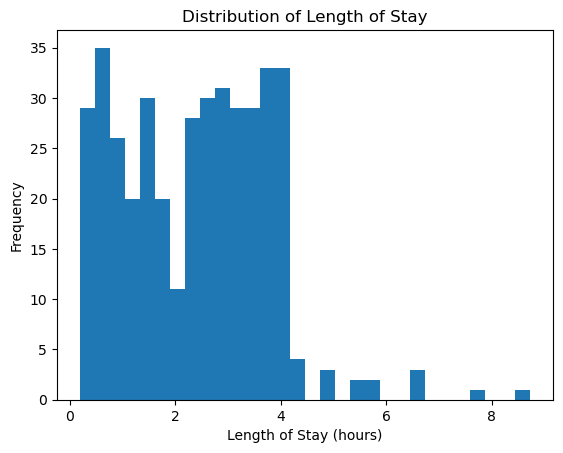

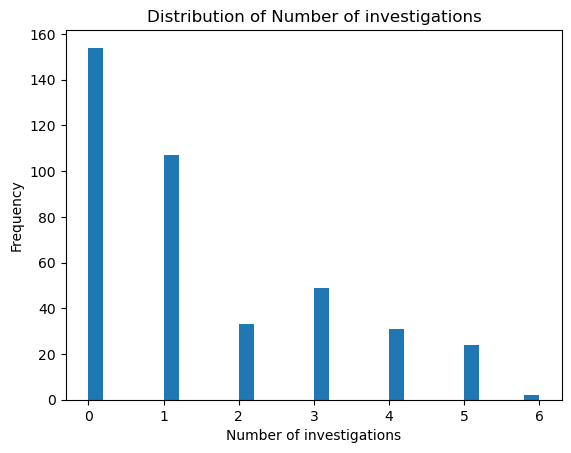

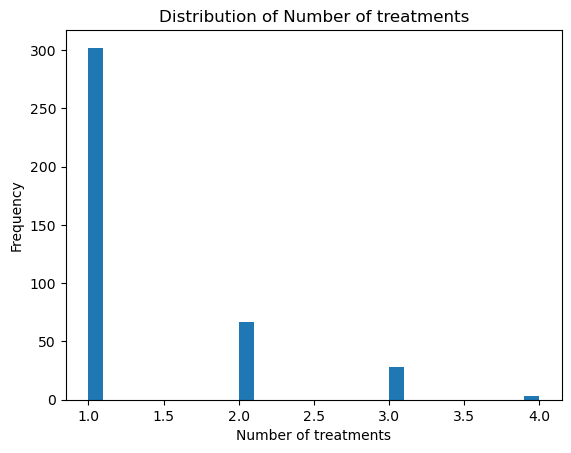

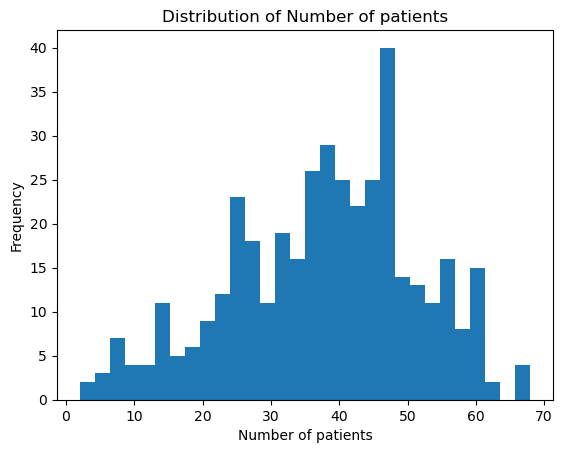

<Figure size 640x480 with 0 Axes>

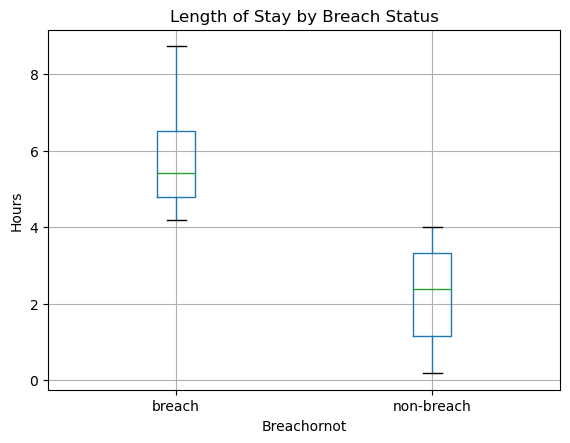


Correlation matrix:
                        LoS       Age    Period  noofpatients  \
LoS                1.000000  0.138947  0.042706      0.147223   
Age                0.138947  1.000000 -0.099248     -0.089672   
Period             0.042706 -0.099248  1.000000      0.516576   
noofpatients       0.147223 -0.089672  0.516576      1.000000   
noofinvestigation  0.514788  0.379565 -0.099161     -0.066427   
nooftreatment     -0.072496 -0.024920 -0.012482      0.056396   

                   noofinvestigation  nooftreatment  
LoS                         0.514788      -0.072496  
Age                         0.379565      -0.024920  
Period                     -0.099161      -0.012482  
noofpatients               -0.066427       0.056396  
noofinvestigation           1.000000      -0.034615  
nooftreatment              -0.034615       1.000000  


In [163]:
# -----------------------------
# Descriptive statistics
# ---------------------------
print("Descriptive statistics:")
print(sample.describe())

# -----------------------------
# Categorical summaries
# -----------------------------
print("\nBreach distribution:")
print(sample["Breachornot"].value_counts())

print("\nDay of week distribution:")
print(sample["DayofWeek"].value_counts())

print("\nNumber of investigation:")
print(sample["noofinvestigation"].value_counts())

print("\nNumber of patients:")
print(sample["nooftreatment"].value_counts())

print("\nNumber of treaments:")
print(sample["noofpatients"].value_counts())


# -----------------------------
# Visualisations
# -----------------------------


# Histogram of Length of Stay
plt.figure()
plt.hist(sample["LoSh"], bins=30)
plt.xlabel("Length of Stay (hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Length of Stay")
plt.show()

# Histogram of No of Investigation
plt.figure()
plt.hist(sample["noofinvestigation"], bins=30)
plt.xlabel("Number of investigations")
plt.ylabel("Frequency")
plt.title("Distribution of Number of investigations")
plt.show()

# Histogram of No of Investigation
plt.figure()
plt.hist(sample["nooftreatment"], bins=30)
plt.xlabel("Number of treatments")
plt.ylabel("Frequency")
plt.title("Distribution of Number of treatments")
plt.show()

# Histogram of No of Patients
plt.figure()
plt.hist(sample["noofpatients"], bins=30)
plt.xlabel("Number of patients")
plt.ylabel("Frequency")
plt.title("Distribution of Number of patients")
plt.show()


# Boxplot of LoS by breach status
plt.figure()
sample.boxplot(column="LoSh", by="Breachornot")
plt.title("Length of Stay by Breach Status")
plt.suptitle("")
plt.ylabel("Hours")
plt.show()

#Correlation matrix 
numeric_vars = [
    "LoS",
    "Age",
    "Period",
    "noofpatients",
    "noofinvestigation",
    "nooftreatment"
]

correlations = sample[numeric_vars].corr()
print("\nCorrelation matrix:") #No of investigations is correlated with LOS
print(correlations)


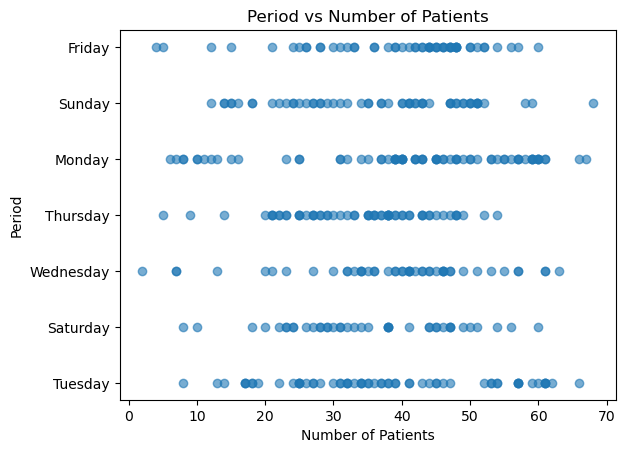

     HRG  Number of patients
0  VB02Z                   1
1  VB03Z                   1
2  VB04Z                   2
3  VB06Z                   1
4  VB07Z                   1
5  VB08Z                   9
6  VB11Z                   1


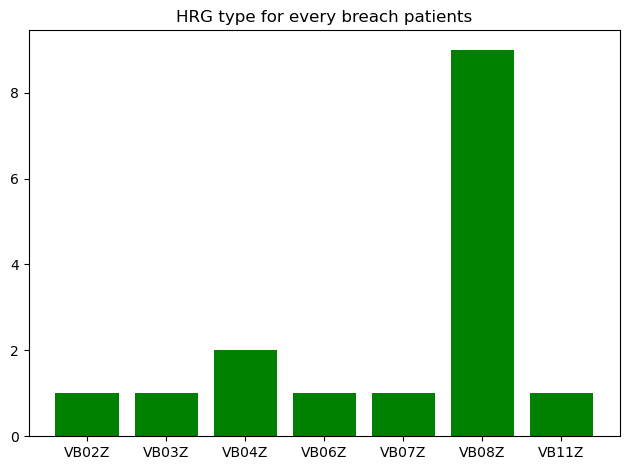

<Figure size 640x480 with 0 Axes>

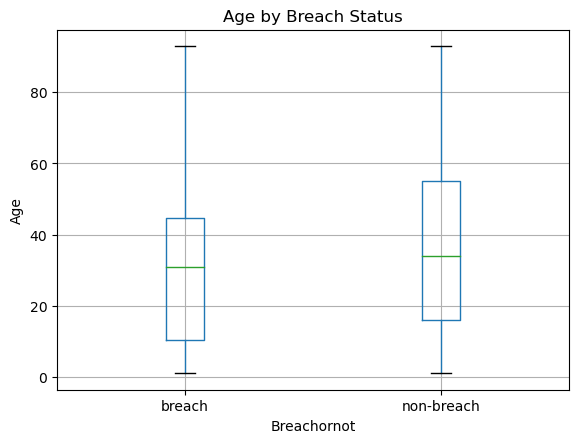

In [164]:

plt.figure()
plt.scatter(
    sample["noofpatients"],
    sample["DayofWeek"],
    alpha=0.6
)
plt.xlabel("Number of Patients")
plt.ylabel("Period")
plt.title("Period vs Number of Patients")
plt.show()



hrb_c = sample[sample['Breachornot'] == 'breach'].groupby('HRG')['ID'].count()
df_plot = hrb_c.reset_index()
df_plot.columns = ['HRG','Number of patients']
print(df_plot)
plt.figure()
plt.title("HRG type for every breach patients")
plt.bar(df_plot['HRG'], df_plot['Number of patients'], color="green", align="center")
plt.tight_layout()
plt.show()
plt.figure()


sample.boxplot(column="Age", by="Breachornot")
plt.title("Age by Breach Status")
plt.suptitle("")
plt.ylabel("Age")
plt.show()

     HRG  Number of investigation
0  VB02Z                 4.000000
1  VB03Z                 2.000000
2  VB04Z                 1.000000
3  VB06Z                 0.000000
4  VB07Z                 3.000000
5  VB08Z                 3.222222
6  VB11Z                 0.000000


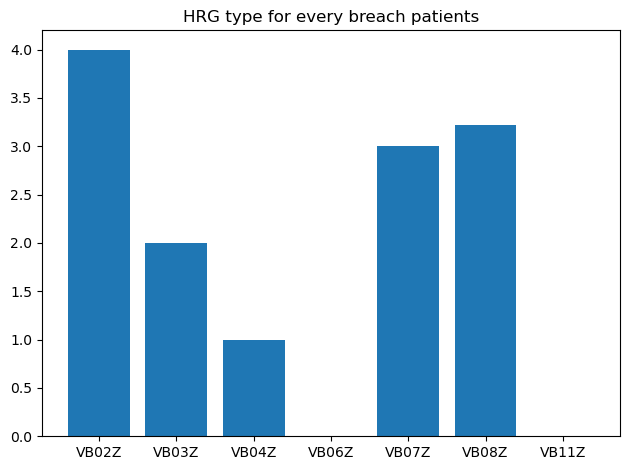

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [131]:
hrb_ci = sample[sample['Breachornot']=='breach'].groupby(['HRG'])['noofinvestigation'].mean()
df_plot1 = hrb_ci.reset_index()
df_plot1.columns = ['HRG','Number of investigation']
print(df_plot1)
plt.figure()
plt.title("HRG type for every breach patients")
plt.bar(df_plot1["HRG"], df_plot1["Number of investigation"])
plt.tight_layout()
plt.show()
plt.figure()

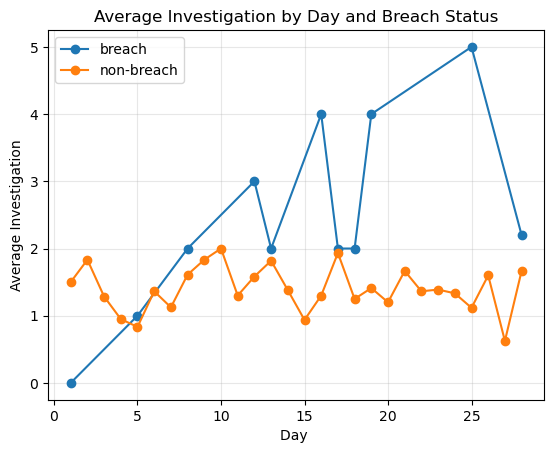

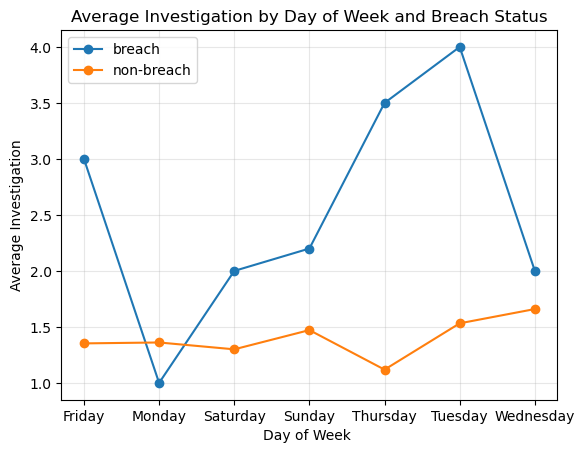

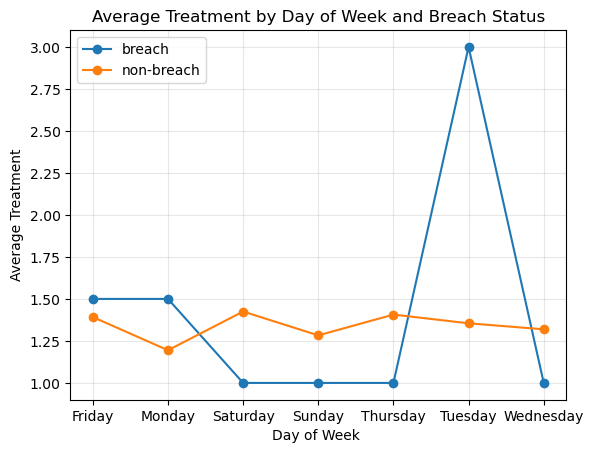

Breachornot
breach        2.500000
non-breach    1.395833
Name: noofinvestigation, dtype: float64
Breachornot
breach        1.312500
non-breach    1.330729
Name: nooftreatment, dtype: float64


In [161]:
x = sample.groupby(['Breachornot','Day'])['noofinvestigation'].mean()
df_plot = x.reset_index()
df_plot.columns = ["Breachornot", "Day", "MeanValue"]
for label in df_plot["Breachornot"].unique():
    subset = df_plot[df_plot["Breachornot"] == label]
    plt.plot(
        subset["Day"],
        subset["MeanValue"],
        marker="o",
        label=label
    )

plt.xlabel("Day ")
plt.ylabel("Average Investigation")
plt.title("Average Investigation by Day and Breach Status")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

x = sample.groupby(['Breachornot','DayofWeek'])['noofinvestigation'].mean()
df_plot = x.reset_index()
df_plot.columns = ["Breachornot", "DayofWeek", "MeanValue"]
for label in df_plot["Breachornot"].unique():
    subset = df_plot[df_plot["Breachornot"] == label]
    plt.plot(
        subset["DayofWeek"],
        subset["MeanValue"],
        marker="o",
        label=label
    )

plt.xlabel("Day of Week ")
plt.ylabel("Average Investigation")
plt.title("Average Investigation by Day of Week and Breach Status")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

x = sample.groupby(['Breachornot','DayofWeek'])['nooftreatment'].mean()
df_plot = x.reset_index()
df_plot.columns = ["Breachornot", "DayofWeek", "MeanValue"]
for label in df_plot["Breachornot"].unique():
    subset = df_plot[df_plot["Breachornot"] == label]
    plt.plot(
        subset["DayofWeek"],
        subset["MeanValue"],
        marker="o",
        label=label
    )

plt.xlabel("Day of Week ")
plt.ylabel("Average Treatment")
plt.title("Average Treatment by Day of Week and Breach Status")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


z = sample.groupby(['Breachornot'])['noofinvestigation'].mean()
print(z)

z1 = sample.groupby(['Breachornot'])['nooftreatment'].mean()
print(z1)

# TASK 6: Machine learning predicting breach

In [9]:

# # Encode categorical columns as integers
# lencoders = {}
# # Loop over the categorical features to encode them
# for col in df.select_dtypes(include=['object']).columns:
#     # Create a label encoder
#     lencoders[col] = LabelEncoder()
#     # Modify the data
#     df[col] = lencoders[col].fit_transform(df[col])


In [3]:
# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("AED4weeks.csv")

# -----------------------------
# Draw random sample (reproducible)
# -----------------------------
RANDOM_SEED = 42
sample = df.sample(n=400, random_state=RANDOM_SEED)
sample['LoSh'] = sample['LoS']/60
df

,ID,Age,Day,DayofWeek,Period,LoS,Breachornot,HRG,noofinvestigation,nooftreatment,noofpatients
0,P10000,4,1,Monday,0,197,non-breach,VB11Z,0,1,25
1,P10001,16,1,Monday,0,66,non-breach,VB11Z,0,1,26
2,P10002,1,1,Monday,0,233,non-breach,VB09Z,0,1,27
3,P10003,31,1,Monday,0,206,non-breach,VB03Z,6,1,26
4,P10004,59,1,Monday,0,232,non-breach,VB08Z,4,1,25
...,...,...,...,...,...,...,...,...,...,...,...
8776,P18776,18,28,Sunday,22,235,non-breach,VB08Z,4,1,49
8777,P18777,48,28,Sunday,22,93,non-breach,VB11Z,0,1,49
8778,P18778,57,28,Sunday,23,188,non-breach,VB09Z,0,1,47
8779,P18779,45,28,Sunday,23,215,non-breach,VB07Z,3,2,42


In [4]:
#Change Period and Day into object and encode Breachornot
df[['Period','Day']] = df[['Period','Day']].astype('object')
df["Breachornot"] = df["Breachornot"].map({
    "non-breach": 0,
    "breach": 1
})


In [5]:
#Change Period and Day into object 

X = df.drop(['Breachornot', 'LoS', 'ID'], axis=1)
y = df['Breachornot']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

## Preprocess for models using one hot encoder
preprocess_ohe = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

## Preprocess for models using label encoder
preprocess_tree = ColumnTransformer([
    ("cat", OrdinalEncoder(), cat_cols),
    ("num", StandardScaler(), num_cols)
])
df

,ID,Age,Day,DayofWeek,Period,LoS,Breachornot,HRG,noofinvestigation,nooftreatment,noofpatients
0,P10000,4,1,Monday,0,197,0,VB11Z,0,1,25
1,P10001,16,1,Monday,0,66,0,VB11Z,0,1,26
2,P10002,1,1,Monday,0,233,0,VB09Z,0,1,27
3,P10003,31,1,Monday,0,206,0,VB03Z,6,1,26
4,P10004,59,1,Monday,0,232,0,VB08Z,4,1,25
...,...,...,...,...,...,...,...,...,...,...,...
8776,P18776,18,28,Sunday,22,235,0,VB08Z,4,1,49
8777,P18777,48,28,Sunday,22,93,0,VB11Z,0,1,49
8778,P18778,57,28,Sunday,23,188,0,VB09Z,0,1,47
8779,P18779,45,28,Sunday,23,215,0,VB07Z,3,2,42


In [17]:
np.random.seed(42)
# ### Training and Test set split 
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.1, stratify = y,random_state=42)

### Hyper-Parameters Optimization of RF using Random Search

pipe_rf = Pipeline([
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])


param_dist = {
    "rf__n_estimators": sp.randint(10,110),
    "rf__criterion": ["gini", "entropy"],
    "rf__max_features": sp.uniform(0.1, 0.9),
    "rf__min_samples_split": sp.uniform(0.01, 0.49)
}
combs = 50
rf = RandomizedSearchCV(pipe_rf, param_dist,scoring = 'f1', n_iter = combs,cv=10,random_state=42)
rf.fit(x_train,y_train)
print('RF best CV:',rf.best_score_,)
print('RF score on test set:', rf.score(x_test,y_test))

### Hyper-Parameters Optimization of LogisticRegression using Grid Search

pipe_lr = Pipeline([
    ("preprocess", preprocess_ohe),
    ("smote", SMOTE(random_state=42)),
    ("logit", LogisticRegression(max_iter=1000, random_state=42))
])


param_grid = {
    "logit__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logit__penalty": ["l1", "l2"],
    "logit__solver": ["liblinear"],
    "logit__class_weight": [None, "balanced"]
}
lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid,
    scoring="f1",
    cv=10,
    n_jobs=-1
)
lr.fit(x_train,y_train)
print('LR best CV:', lr.best_score_)
print('LR score on the test set:', lr.score(x_test,y_test))

### Hyper-Parameters Optimization of GradientBoosting using Grid Search

pipe_gb = Pipeline([
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))
])


param_gb = {
    "gb__n_estimators": [100, 200],
    "gb__learning_rate": [0.05, 0.1],
    "gb__max_depth": [3, 5]
}

gb_search = GridSearchCV(
    pipe_gb,
    param_grid=param_gb,
    scoring="f1",
    cv=10,
    n_jobs=-1
)

gb_search.fit(x_train, y_train)
print("GB best CV:", gb_search.best_score_)
print("GB score on test set:", gb_search.score(x_test,y_test))

### Hyper-Parameters Optimization of DecisionTree using Grid Search

pipe_dt = Pipeline([
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42))
])


param_dt = {
    "dt__max_depth": [3, 5, 8, 12, None],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 5, 10]
}

dt_search = GridSearchCV(
    pipe_dt,
    param_grid=param_dt,
    scoring="f1",
    cv=10,
    n_jobs=-1
)

dt_search.fit(x_train, y_train)
print("DT best CV:", dt_search.best_score_)
print("DT score on the test set:", dt_search.score(x_test,y_test))

### Hyper-Parameters Optimization of SVM using Grid Search

pipe_svm = Pipeline([
    ("preprocess", preprocess_ohe),
    ("smote", SMOTE(random_state=42)),
    ("svm", SVC(probability=True, random_state=42))
])


param_svm = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["rbf"],
    "svm__gamma": ["scale", 0.01, 0.1]
}

svm_search = GridSearchCV(
    pipe_svm,
    param_grid=param_svm,
    scoring="f1",
    cv=10,
    n_jobs=-1
)

svm_search.fit(x_train, y_train)
print("SVM best CV:", svm_search.best_score_)
print("SVM score on the test set:",  svm_search.score(x_test,y_test))


RF best CV: 0.2462437142543724
RF score on test set: 0.3076923076923077
LR best CV: 0.1622112456779303
LR score on the test set: 0.18867924528301885
GB best CV: 0.2754644213395744
GB score on test set: 0.2978723404255319
DT best CV: 0.20241644676187623
DT score on the test set: 0.2898550724637681
SVM best CV: 0.21430983324484645
SVM score on the test set: 0.2191780821917808


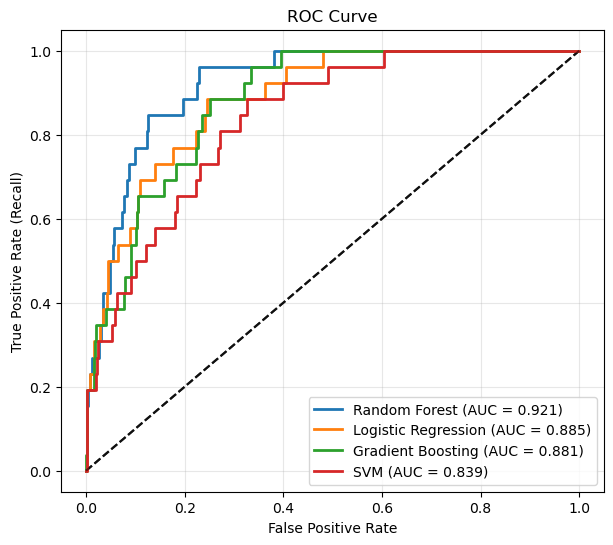

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(model, X_test, y_test, label=None):
    """
    Plot ROC curve for a fitted model.
    """

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Plot
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(alpha=0.3)

    return auc
plt.figure(figsize=(7, 6))

plot_roc_curve(rf.best_estimator_, x_test, y_test, label="Random Forest")
plot_roc_curve(lr.best_estimator_, x_test, y_test, label="Logistic Regression")
plot_roc_curve(gb_search.best_estimator_, x_test, y_test, label="Gradient Boosting")
plot_roc_curve(svm_search.best_estimator_, x_test, y_test, label="SVM")

plt.show()


In [19]:

def evaluate_models_cv(models, X, y, cv=5, scoring=None):
    """
    models: dict of {model_name: pipeline}
    X, y: full training data
    cv: number of folds
    scoring: list or dict of metrics
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    results = []

    for name, model in models.items():
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=scoring,
            return_train_score=False
        )

        summary = {
            "Model": name
        }

        for metric in cv_results:
            if metric.startswith("test_"):
                summary[metric.replace("test_", "")] = (
                    np.mean(cv_results[metric]),
                    np.std(cv_results[metric])
                )

        results.append(summary)

    return pd.DataFrame(results)


In [20]:
models_optimized = {
    "Logistic Regression": lr.best_estimator_,
    "Random Forest": rf.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
    "Decision Tree": dt_search.best_estimator_
}
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}
cv_results = evaluate_models_cv(models_optimized, x_train, y_train, cv=10, scoring=(['roc_auc','precision','recall','f1']))
print(pd.DataFrame(round(cv_results,4)))
# Best model is between LR, RF, and SVM. However, the F1 score of RF is noticeably higher -> final model is RF

                 Model                                    roc_auc  \
0  Logistic Regression  (0.8242469844114131, 0.04554252371379587)   
1        Random Forest  (0.8185339334687386, 0.04153593016287904)   
2                  SVM  (0.7885970831853893, 0.04238472279491591)   
3    Gradient Boosting  (0.8133249765078177, 0.04152233963319778)   
4        Decision Tree   (0.6786385954760917, 0.0611174937817281)   

                                     precision  \
0  (0.08960850829238733, 0.013760465487477929)   
1     (0.2243921964703198, 0.0689027817702922)   
2   (0.14381153722961443, 0.04672889185622957)   
3     (0.3149134199134199, 0.1337760669167738)   
4   (0.18527666011624636, 0.06190009811015663)   

                                       recall  \
0   (0.6826086956521739, 0.11785335798634608)   
1  (0.33115942028985507, 0.12332899053986633)   
2   (0.2967391304347826, 0.10582191489836983)   
3  (0.18496376811594203, 0.06523475010527785)   
4   (0.2498188405797102, 0.090200110387

In [21]:
best_svm = svm_search.best_estimator_
best_rf = rf.best_estimator_
best_lr = lr.best_estimator_
best_gb = gb_search.best_estimator_
best_dt = dt_search.best_estimator_
### Confusion matrix
y_pred_rf = best_rf.predict(x_test)
cm_rf = confusion_matrix(y_test,y_pred_rf,labels = [0,1])
print('RF confusion matrix')
print(cm_rf)

y_pred_svm = best_svm.predict(x_test)
cm_svm = confusion_matrix(y_test,y_pred_svm,labels = [0,1])
print('SVM confusion matrix')
print(cm_svm)

y_pred_lr = best_lr.predict(x_test)
cm_lr = confusion_matrix(y_test,y_pred_lr,labels = [0,1])
print('LR confusion matrix')
print(cm_lr)

y_pred_gb = best_gb.predict(x_test)
cm_gb = confusion_matrix(y_test,y_pred_gb,labels = [0,1])
print('GB confusion matrix')
print(cm_gb)

y_pred_dt = best_dt.predict(x_test)
cm_dt= confusion_matrix(y_test,y_pred_dt,labels = [0,1])
print('DT confusion matrix')
print(cm_dt)

# #print(classification_report(y_test, y_pred))
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.plot([0,1], [0,1], "k--", label="Random")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()

# target_tpr = 0.97
# idx = (tpr >= target_tpr).argmax()
# threshold = thresholds[idx]
# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.scatter(fpr[idx], tpr[idx], color="red", zorder=5,
#             label=f"Chosen threshold = {threshold:.3f}")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve with Selected Operating Point")
# plt.legend()
# plt.show()


# #Change the threshold
# threshold = 0.5381471405094274
# y_pred_thresh = (y_prob >= threshold).astype(int)

# confusion_matrix(y_test, y_pred_thresh)

RF confusion matrix
[[824  29]
 [ 16  10]]
SVM confusion matrix
[[814  39]
 [ 18   8]]
LR confusion matrix
[[687 166]
 [  6  20]]
GB confusion matrix
[[839  14]
 [ 19   7]]
DT confusion matrix
[[820  33]
 [ 16  10]]


In [45]:
#threshold tuning
def cv_threshold_tuning(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    thresholds = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)

        # Probabilities
        if hasattr(model, "predict_proba"):
            y_val_prob = model.predict_proba(X_val)[:, 1]
        else:
            y_val_prob = model.decision_function(X_val)

        fpr, tpr, thr = roc_curve(y_val, y_val_prob)
        best_thr = thr[np.argmax(tpr - fpr)]  # Youden’s J
        thresholds.append(best_thr)

    return np.mean(thresholds)
#tuning
best_svm = svm_search.best_estimator_
best_rf = rf.best_estimator_
best_lr = lr.best_estimator_
rf_threshold = cv_threshold_tuning(best_rf, x_train, y_train)
lr_threshold = cv_threshold_tuning(best_lr, x_train, y_train)
svm_threshold = cv_threshold_tuning(best_svm, x_train, y_train)

print("RF CV threshold:", rf_threshold)
print("LR CV threshold:", lr_threshold)
print("SVM CV threshold:", svm_threshold)

y_prob_rf = best_rf.predict_proba(x_test)[:, 1]
y_pred_rf = (y_prob_rf >= rf_threshold).astype(int)

print("Random Forest Test Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

y_prob_lr = best_lr.predict_proba(x_test)[:, 1]
y_pred_lr = (y_prob_lr >= lr_threshold).astype(int)

print("Logistic Regression Test Results")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

y_prob_svm = best_svm.predict_proba(x_test)[:, 1]
y_pred_svm = (y_prob_lr >= svm_threshold).astype(int)

print("SVM Test Results")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))


RF CV threshold: 0.16466834417661833
LR CV threshold: 0.39631752240314283
SVM CV threshold: 0.27430235781750845
Random Forest Test Results
[[504 349]
 [  0  26]]
              precision    recall  f1-score   support

           0       1.00      0.59      0.74       853
           1       0.07      1.00      0.13        26

    accuracy                           0.60       879
   macro avg       0.53      0.80      0.44       879
weighted avg       0.97      0.60      0.72       879

ROC-AUC: 0.8993146361258906
Logistic Regression Test Results
[[608 245]
 [  2  24]]
              precision    recall  f1-score   support

           0       1.00      0.71      0.83       853
           1       0.09      0.92      0.16        26

    accuracy                           0.72       879
   macro avg       0.54      0.82      0.50       879
weighted avg       0.97      0.72      0.81       879

ROC-AUC: 0.8930471638560735
SVM Test Results
[[521 332]
 [  1  25]]
              precision    recal

             feature  importance
0  noofinvestigation    0.574727
1             Period    0.156000
2                Age    0.130674
3      nooftreatment    0.035841
4          DayofWeek    0.032260
5                Day    0.030083
6       noofpatients    0.025976
7                HRG    0.014440


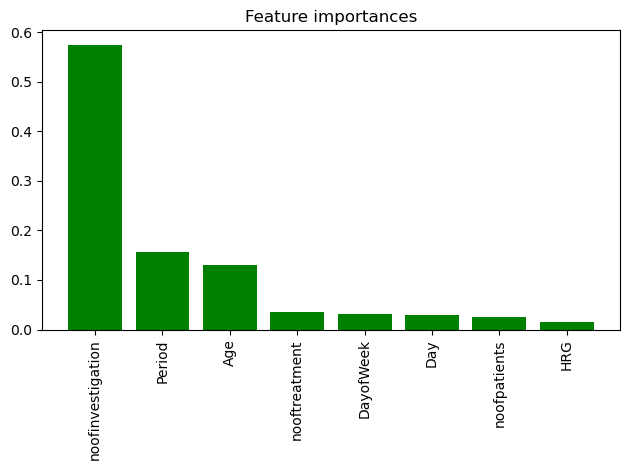

In [22]:
# Feature Importance
rf_model = best_rf.named_steps["rf"]
importances = rf_model.feature_importances_
indices = np.argsort(-importances)
df_imp = pd.DataFrame(dict(feature = x_train.columns[indices],importance = importances[indices]))
print(df_imp)

# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(len(importances)), df_imp['importance'], color="green", align="center")
plt.xticks(range(len(importances)), df_imp['feature'], rotation=90)
plt.tight_layout()
plt.show()

In [28]:
## MLP Regression 
np.random.seed(42)
x_train1, x_test1, y_train1, y_test1 = train_test_split(df.drop(['Breachornot','LoS','ID'],axis=1),df['LoS'],test_size = 0.1, random_state=42)
y_train1_log = np.log1p(y_train1)
y_test1_log = np.log1p(y_test1)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        max_iter=30000,
        random_state=42
    ))
])

pipe_param_dist = dict(mlp__hidden_layer_sizes = sp. randint (5,20, (1,1)),
                       mlp__solver = ['lbfgs', 'adam'])

random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=pipe_param_dist,
                                   n_iter=20, 
                                   cv=5, 
                                   n_jobs = 2,
                                   random_state=42)
random_search.fit(x_train1,y_train1_log)
print("Best parameters:", random_search.best_params_)
print("Mean CV R²:", random_search.best_score_)
print("Test R²:", random_search.score(x_test1, y_test1_log))

Best parameters: {'mlp__hidden_layer_sizes': array([ 7, 17]), 'mlp__solver': 'lbfgs'}
Mean CV R²: 0.3951203541882825
Test R²: 0.3993004359808452


In [33]:
# ### Confusion matrix
# y_pred = dt_search.predict(x_test)
# y_prob = dt_search.predict_proba(x_test)[:, 1]
# cm = confusion_matrix(y_test,y_pred,labels = [0,1])
# print(cm)
# #print(classification_report(y_test, y_pred))
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.plot([0,1], [0,1], "k--", label="Random")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()

# target_tpr = 0.97
# idx = (tpr >= target_tpr).argmax()
# threshold = thresholds[idx]
# plt.figure(figsize=(6,6))
# plt.plot(fpr, tpr, label="ROC curve")
# plt.scatter(fpr[idx], tpr[idx], color="red", zorder=5,
#             label=f"Chosen threshold = {threshold:.3f}")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve with Selected Operating Point")
# plt.legend()
# plt.show()


# #Change the threshold
# threshold = 0.5381471405094274
# y_pred_thresh = (y_prob >= threshold).astype(int)

# confusion_matrix(y_test, y_pred_thresh)

In [32]:
# from sklearn.linear_model import LogisticRegression
# logit = LogisticRegression(max_iter=1000)
# logit.fit(x_train, y_train)
# logit.score(x_test,y_test)
# y_pred_logit = logit.predict(x_test)
# conf_mat = confusion_matrix(y_test, y_pred_logit)
# conf_mat

# y_prob_logit = logit.predict_proba(x_test)[:, 1]
# plt.hist(y_prob_logit[y_test == 0], alpha=0.6, label="Breach")
# plt.hist(y_prob_logit[y_test == 1], alpha=0.6, label="Non-breach")
# plt.legend()
# plt.xlabel("Predicted probability of non-breach")
# plt.show()
# threshold = 0.98
# y_pred_thresh = (y_prob_logit >= threshold).astype(int)

# confusion_matrix(y_test, y_pred_thresh)

# best_lr = lr.best_estimator_
# y_pred_logit = best_lr.predict(x_test)
# y_prob_logit = logit.predict_proba(x_test)[:, 1]
# print(confusion_matrix(y_test, y_pred_logit))
# threshold = 0.97

# y_pred_thresh = (y_prob_logit >= threshold).astype(int)

# print(confusion_matrix(y_test, y_pred_thresh))

In [ ]:
import pandas as pd
import logging
from datetime import datetime

In [3]:
from datetime import datetime
import pandas as pd
import logging
import os

# --- LOGGING SETUP ---

logging.basicConfig(
    filename="audit_log.txt",
    level=logging.INFO,
    format="%(asctime)s - %(message)s"
)


def log_action(action):
    print(f"Action Logged: {action}")
    logging.info(action)

# --- DATA LOADING ---
df = pd.read_csv('AED4weeks.csv')

def get_patient_by_id(df):
    pid = input("Enter patient ID: ")

    result = df[df["ID"].astype(str) == pid]

    if result.empty:
        print("❌ Patient not found.")
        logging.info(f"Attempted retrieval of non-existent patient ID {pid}")
    else:
        print("\nPatient record:")
        print(result)
        logging.info(f"Retrieved patient ID {pid}")
def filter_by_range(df):
    print("Available columns:")
    print(list(df.columns))

    col = input("Enter variable name: ")

    if col not in df.columns:
        print("❌ Invalid variable.")
        return

    try:
        min_val = float(input("Enter minimum value: "))
        max_val = float(input("Enter maximum value: "))
    except ValueError:
        print("❌ Invalid numeric input.")
        return

    result = df[(df[col] >= min_val) & (df[col] <= max_val)]

    print(f"\nPatients with {col} between {min_val} and {max_val}:")
    print(result)

    logging.info(f"Filtered patients on {col} between {min_val} and {max_val}")
def modify_patient(df):
    pid = input("Enter patient ID to modify: ")

    idx = df[df["ID"].astype(str) == pid].index

    if len(idx) == 0:
        print("❌ Patient not found.")
        return

    print("Available columns:")
    print(list(df.columns))

    col = input("Enter column to modify: ")

    if col not in df.columns:
        print("❌ Invalid column.")
        return

    old_value = df.loc[idx[0], col]
    new_value = input("Enter new value: ")

    confirm = input(f"Confirm change {col}: {old_value} → {new_value}? (Y/N): ")

    if confirm.upper() == "Y":
        df.loc[idx[0], col] = new_value
        print("✅ Record updated.")
        logging.info(
            f"Modified patient ID {pid}: {col} changed from {old_value} to {new_value}"
        )
    else:
        print("❌ Modification cancelled.")
def delete_patient(df):
    pid = input("Enter patient ID to delete: ")

    idx = df[df["ID"].astype(str) == pid].index

    if len(idx) == 0:
        print("❌ Patient not found.")
        return

    confirm = input(f"Are you sure you want to delete patient {pid}? (Y/N): ")

    if confirm.upper() == "Y":
        df.drop(idx, inplace=True)
        print("✅ Patient deleted.")
        logging.info(f"Deleted patient ID {pid}")
    else:
        print("❌ Deletion cancelled.")

def menu():
    print("\n========== Patient Data Management ==========")
    print("1. Retrieve patient by ID")
    print("2. Filter patients by variable range")
    print("3. Modify patient record")
    print("4. Delete patient record")
    print("5. Exit")
    print("6. Log file")
def view_logs():
    try:
        with open("audit_log.txt", "r") as f:
            print("\n===== SYSTEM LOG =====")
            print(f.read())
    except FileNotFoundError:
        print("No log file found.")

In [4]:

while True:
    menu()
    choice = input("Select an option (1–6): ")

    if choice == "1":
        get_patient_by_id(df)

    elif choice == "2":
        filter_by_range(df)

    elif choice == "3":
        modify_patient(df)

    elif choice == "4":
        delete_patient(df)

    elif choice == "5":
        print("Exiting program.")
        logging.info("Program exited by user.")
        break
    elif choice == "6":
        view_logs()

    else:
        print("❌ Invalid selection. Try again.")



========== Patient Data Management ==========
1. Retrieve patient by ID
2. Filter patients by variable range
3. Modify patient record
4. Delete patient record
5. Exit
6. Log file
Select an option (1–6): 1
Enter patient ID: P10043

Patient record:
        ID  Age  Day DayofWeek  Period  LoS Breachornot    HRG  \
43  P10043   77    1    Monday       9  125  non-breach  VB11Z   

    noofinvestigation  nooftreatment  noofpatients  
43                  0              1            17  

========== Patient Data Management ==========
1. Retrieve patient by ID
2. Filter patients by variable range
3. Modify patient record
4. Delete patient record
5. Exit
6. Log file
Select an option (1–6): 2
Available columns:
['ID', 'Age', 'Day', 'DayofWeek', 'Period', 'LoS', 'Breachornot', 'HRG', 'noofinvestigation', 'nooftreatment', 'noofpatients']
Enter variable name: Age
Enter minimum value: 34
Enter maximum value: 35

Patients with Age between 34.0 and 35.0:
          ID  Age  Day DayofWeek  Period  LoS 

In [6]:
pip install streamlit

  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/c0/95/6b7873f0267973ebd55ba9cd33a690b35a116f2779901ef6185a0e21864d/streamlit-1.52.2-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/db/33/ef2f2409450ef6daa61459d5de5c08128e7d3edb773fefd0a324d1310238/altair-6.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for blinker<2,>=1.5.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<7,>=4.0 from https://files.pythonhosted.org/packages/2c/fc/1d7b80d0eb7b714984ce40efc78859c022cd930e402f599d8ca9e39c78a4/cachetools-6.2.4-py3-none-any.whl.metadata
  Obtaining dependency information for protobuf<7,>=3.20 from https://files.pythonhosted.org/packages/b2/ca/7e485da88ba45c920fb3f50ae78de29ab925d9e54ef0d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 5.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.8/430.8 kB 4.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.7.1
    Uninstalling typing_extensions-4.7.1:
      Successfully uninstalled typing_extensions-4.7.1
Note: you may need to restart the kernel to use updated packages.
